# ChronoLux Data Analysis Pipeline

This notebook processes the raw telemetry CSV data generated by the ChronoLux Digital Twin simulation engine. It is responsible for parsing hourly exposure data, resampling it into daily aggregates, and generating high-quality visualizations used in the final academic paper.

## 1. Environment Setup & Imports
First, we load the required Python data science libraries and set the styling to match the IEEE/ACM double-column format constraints.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import os

# Ensure clean output directory
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# Set high-quality styling for IEEE/ACM papers
plt.style.use('seaborn-v0_8-paper')
sns.set_theme(style="whitegrid", font_scale=1.2)

# Custom color palette for the scenarios to ensure visual distinction
colors = {"Scenario A (Baseline)": "#d62728", # Red
          "Scenario B (Materials)": "#ff7f0e", # Orange
          "Scenario C (Position)": "#1f77b4", # Blue
          "Scenario D (Combined)": "#2ca02c"} # Green

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Loading & Preprocessing

Here we load the 4 simulated scenarios:
- **Scenario A (Baseline)**: Untreated museum conditions (Clear glass, reflective surfaces).
- **Scenario B (Materials)**: Material intervention (UV-blocking glass, matte floor).
- **Scenario C (Position)**: Positional intervention (Asset placed in occlusion).
- **Scenario D (Combined)**: Combined material and positional optimizations.

We also aggregate the raw hourly data into daily summaries for macro-scale visualizations.

In [40]:
print("Loading CSV data and preprocessing...")
files = {
    "Scenario A (Baseline)": "scenario_a.csv",
    "Scenario B (Materials)": "scenario_b.csv",
    "Scenario C (Position)": "scenario_c.csv",
    "Scenario D (Combined)": "scenario_d.csv"
}

dfs = {}        # Hourly data (for high-res profiling)
dfs_daily = {}  # Daily data (for cleaner macro-scale plots)

for label, filename in files.items():
    df = pd.read_csv(filename)
    df['Time'] = pd.to_datetime(df['Time'])
    # Scale to kLux-Hours for cleaner Y-axis labels
    df['MaxDose_kLux'] = df['MaxDose'] / 1000.0
    df['AvgDose_kLux'] = df['AvgDose'] / 1000.0
    
    dfs[label] = df
    
    # --- Preprocessing: Resample to Daily Frequency ---
    df_set = df.set_index('Time')
    df_daily = df_set.resample('1D').agg({
        'MaxDose_kLux': 'max',        # Cumulative metric: take max of the day
        'AvgDose_kLux': 'max',        # Cumulative metric: take max of the day
        'DoseVariance': 'mean',       # Average contrast stress over the day
        'AvgSensorErrorPct': 'mean',  # Average daily convergence error
        'DeltaMaxDose': 'max',        # Peak hourly hit across that specific day
        'BeamLux': 'mean',
        'DiffuseLux': 'mean'
    }).reset_index()
    dfs_daily[label] = df_daily

print("Data loaded and preprocessed (Hourly & Daily variants created).")

Loading CSV data and preprocessing...
Data loaded and preprocessed (Hourly & Daily variants created).


## 3. Cumulative Exposure Plots

### Figure 1: Cumulative Peak and Average Dose
These graphs illustrate the long-term accumulation of light energy (in Lux-Hours) across the entire meteorological year. We plot both the **Peak Dose** (maximum stress point) and the **Average Dose**.

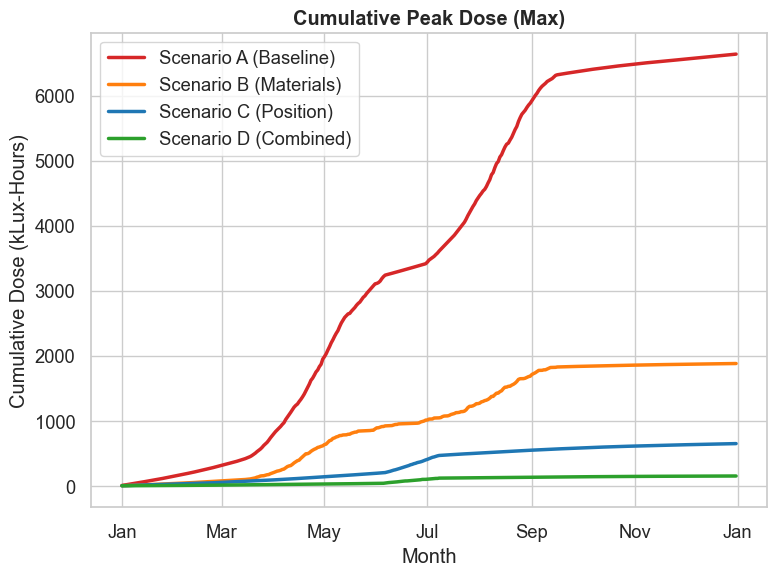

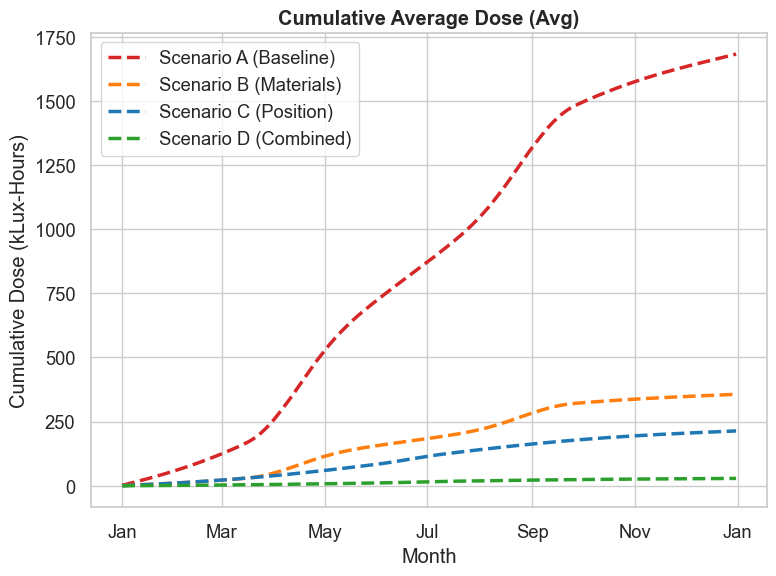

In [41]:
# ==========================================
# Fig 1A: Cumulative Peak Dose (Max)
# ==========================================
fig, ax1 = plt.subplots(figsize=(8, 6))
for label, df_d in dfs_daily.items():
    ax1.plot(df_d['Time'], df_d['MaxDose_kLux'], label=label, color=colors[label], linewidth=2.5)
ax1.set_title('Cumulative Peak Dose (Max)', fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Cumulative Dose (kLux-Hours)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax1.legend()
plt.tight_layout()
plt.savefig(f'{output_dir}/fig1a_cumulative_max_dose.png', dpi=300)
plt.show()
plt.close()

# ==========================================
# Fig 1B: Cumulative Average Dose (Avg)
# ==========================================
fig, ax2 = plt.subplots(figsize=(8, 6))
for label, df_d in dfs_daily.items():
    ax2.plot(df_d['Time'], df_d['AvgDose_kLux'], label=label, color=colors[label], linewidth=2.5, linestyle='--')
ax2.set_title('Cumulative Average Dose (Avg)', fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Cumulative Dose (kLux-Hours)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax2.legend(loc='upper left')
plt.tight_layout()
plt.savefig(f'{output_dir}/fig1b_cumulative_avg_dose.png', dpi=300)
plt.show()
plt.close()

### Figure 2: Final End-of-Year Impact Summary

This bar chart compares the final cumulative dose at hour 8760 across all scenarios. It highlights the drastic reduction in total exposure achieved by the combined conservation strategies in Scenario D.

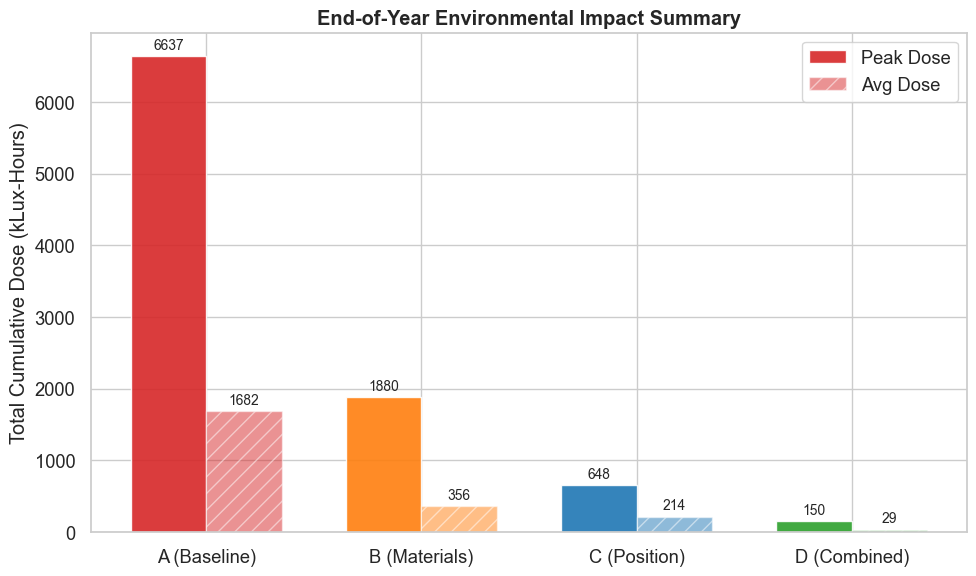

In [42]:
# ==========================================
# Fig 2: Final Dose Bar Chart
# ==========================================
labels = list(dfs_daily.keys())
final_max = [df_d['MaxDose_kLux'].iloc[-1] for df_d in dfs_daily.values()]
final_avg = [df_d['AvgDose_kLux'].iloc[-1] for df_d in dfs_daily.values()]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, final_max, width, label='Peak Dose', color=[colors[l] for l in labels], alpha=0.9)
rects2 = ax.bar(x + width/2, final_avg, width, label='Avg Dose', color=[colors[l] for l in labels], alpha=0.5, hatch='//')

ax.set_ylabel('Total Cumulative Dose (kLux-Hours)')
ax.set_title('End-of-Year Environmental Impact Summary', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([l.replace("Scenario ", "") for l in labels])
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.0f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)
autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig(f'{output_dir}/fig2_final_dose_bar.png', dpi=300)
plt.show()
plt.close()

## 4. Metrology & Convergence Analysis

### Figure 3: Spatial Variance and Sensor Error
To scientifically validate the Digital Twin, we track the spatial variance of light across the artifact's surface, as well as the Monte Carlo convergence error reported by the virtual Lux sensors.

*Note: We apply a 7-day rolling average to the Scenario B variance curve to filter out high-frequency noise and highlight the underlying structural trend.*

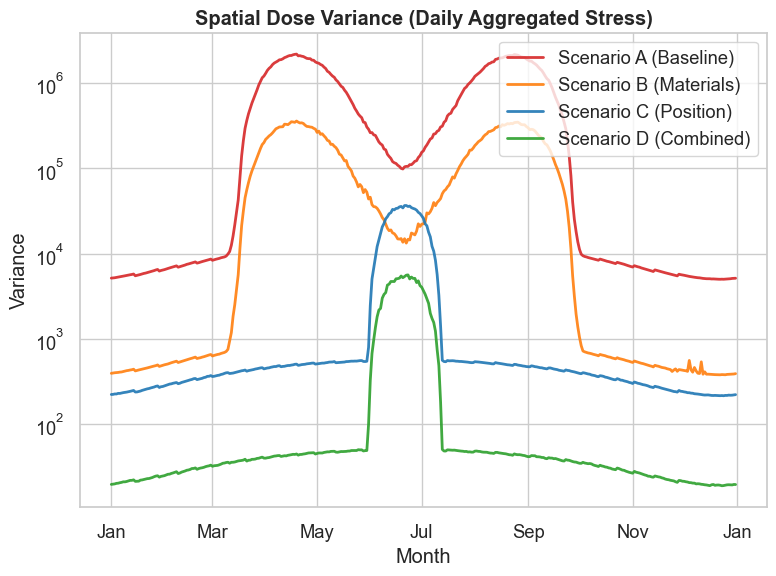

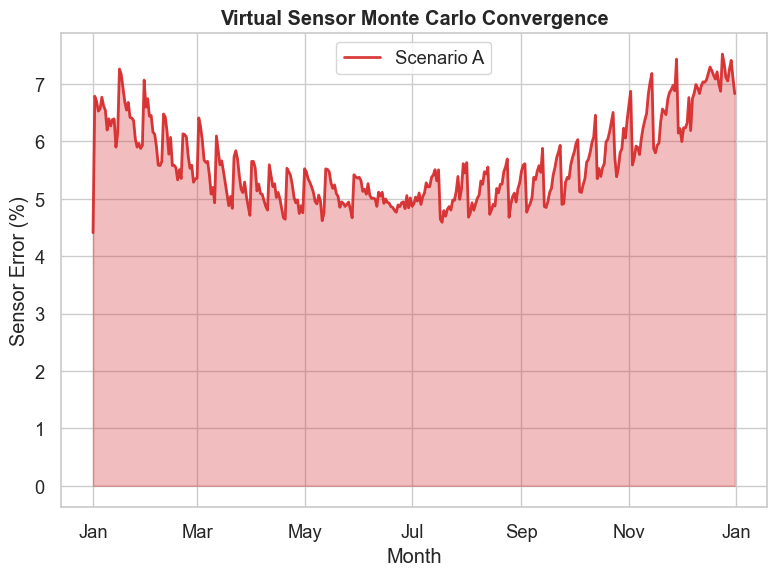

In [43]:
# ==========================================
# Fig 3A: Spatial Dose Variance
# ==========================================
fig, ax1 = plt.subplots(figsize=(8, 6))
for label, df_d in dfs_daily.items():
    y_data = df_d['DoseVariance']
    ax1.plot(df_d['Time'], y_data, label=label, color=colors[label], linewidth=2.0, alpha=0.9)
ax1.set_title('Spatial Dose Variance (Daily Aggregated Stress)', fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Variance')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax1.set_yscale('log')
ax1.legend()
plt.tight_layout()
plt.savefig(f'{output_dir}/fig3a_spatial_dose_variance.png', dpi=300)
plt.show()
plt.close()

# ==========================================
# Fig 3B: Hardware Sensor Convergence Error
# ==========================================
fig, ax2 = plt.subplots(figsize=(8, 6))
df_a_d = dfs_daily["Scenario A (Baseline)"]
ax2.plot(df_a_d['Time'], df_a_d['AvgSensorErrorPct'], color=colors["Scenario A (Baseline)"], linewidth=2.0, alpha=0.9, label='Scenario A')
ax2.set_title('Virtual Sensor Monte Carlo Convergence', fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Sensor Error (%)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax2.fill_between(df_a_d['Time'], 0, df_a_d['AvgSensorErrorPct'], color=colors["Scenario A (Baseline)"], alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.savefig(f'{output_dir}/fig3b_monte_carlo_convergence.png', dpi=300)
plt.show()
plt.close()

## 5. Temporal Heatmaps

### Figure 4: Diurnal Exposure Profile
This scatter plot acts as a temporal heat map, showing precisely at what time of day (Y-axis) and what time of year (X-axis) the artifact receives its peak irradiance.

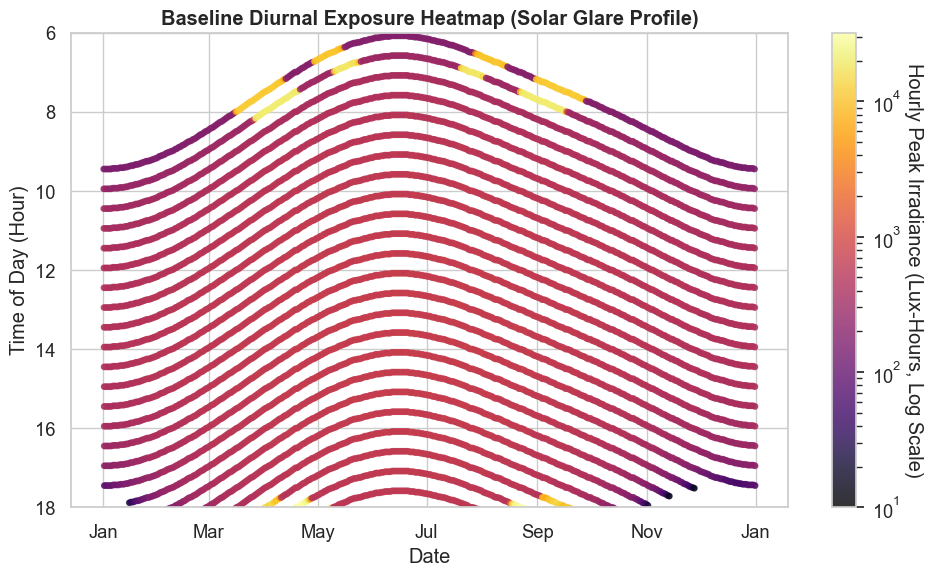

In [44]:
# ==========================================
# Fig 4: Diurnal Exposure Heatmap
# ==========================================
df_a = dfs["Scenario A (Baseline)"]
df_a_day = df_a.copy()
df_a_day['Hour'] = df_a_day['Time'].dt.hour + df_a_day['Time'].dt.minute / 60.0

fig, ax = plt.subplots(figsize=(10, 6))
df_plot = df_a_day[df_a_day['DeltaMaxDose'] > 5]

scatter = ax.scatter(df_plot['Time'], df_plot['Hour'], 
                      c=df_plot['DeltaMaxDose'], cmap='inferno', 
                      norm=mcolors.LogNorm(vmin=10, vmax=df_plot['DeltaMaxDose'].max()),
                      s=15, alpha=0.8)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Hourly Peak Irradiance (Lux-Hours, Log Scale)', rotation=270, labelpad=15)

ax.set_title('Baseline Diurnal Exposure Heatmap (Solar Glare Profile)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Time of Day (Hour)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.invert_yaxis()
ax.set_ylim(18, 6)

plt.tight_layout()
plt.savefig(f'{output_dir}/fig4_diurnal_heatmap.png', dpi=300)
plt.show()
plt.close()

## 6. Illuminance Composition Analysis

### Figure 5: Direct vs. Diffuse Radiation (NEE Validation)
By separating the total irradiance into Direct Beam and Diffuse Sky components (via Next Event Estimation), we can prove that our geometric occlusion intervention (Scenario D) successfully filters direct sunlight, isolating the effects of ambient skylight.

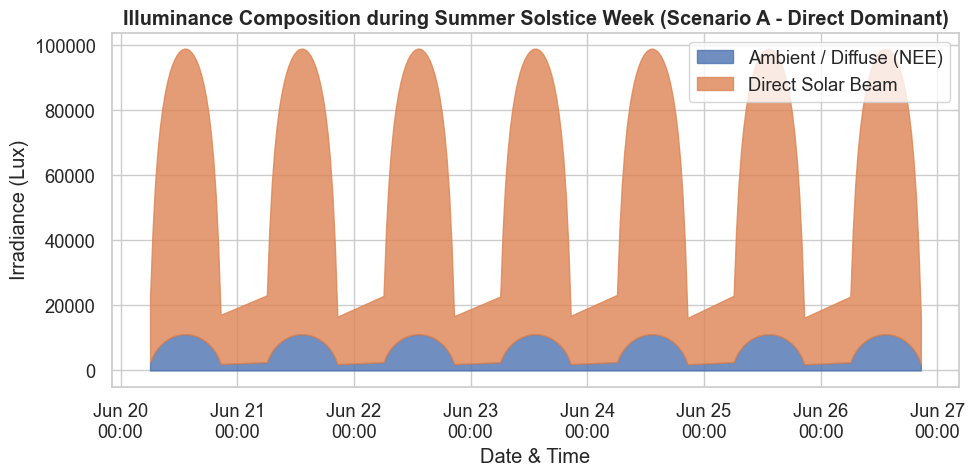

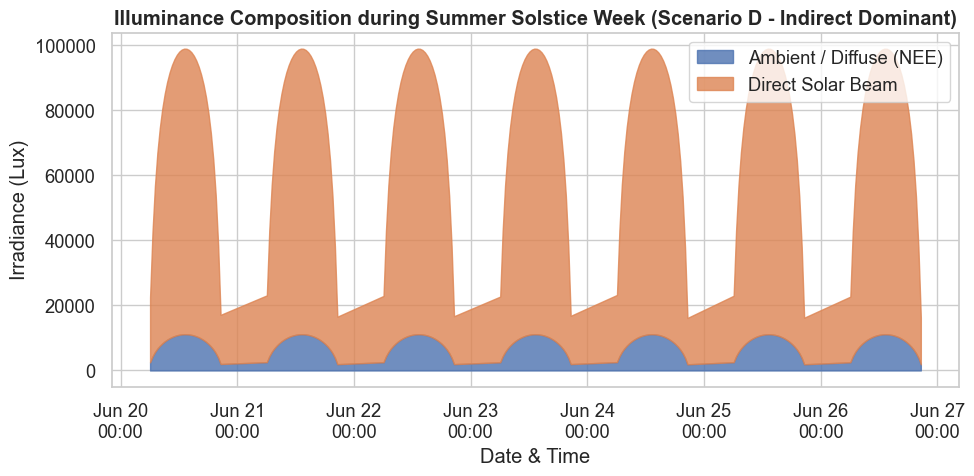

All figures successfully saved in 'figures/' directory.


In [45]:
# ==========================================
# Fig 5A: Illuminance Composition (Scenario A)
# ==========================================
mask_a = (df_a['Time'] >= '2026-06-20') & (df_a['Time'] <= '2026-06-27')
df_week_a = df_a.loc[mask_a]

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(df_week_a['Time'], 0, df_week_a['DiffuseLux'], label='Ambient / Diffuse (NEE)', color='#4c72b0', alpha=0.8)
ax.fill_between(df_week_a['Time'], df_week_a['DiffuseLux'], df_week_a['DiffuseLux'] + df_week_a['BeamLux'], 
                 label='Direct Solar Beam', color='#dd8452', alpha=0.8)

ax.set_title('Illuminance Composition during Summer Solstice Week (Scenario A - Direct Dominant)', fontweight='bold')
ax.set_xlabel('Date & Time')
ax.set_ylabel('Irradiance (Lux)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'{output_dir}/fig5a_beam_vs_diffuse.png', dpi=300)
plt.show()
plt.close()

# ==========================================
# Fig 5B: Illuminance Composition (Scenario D)
# ==========================================
df_d = dfs["Scenario D (Combined)"]
mask_d = (df_d['Time'] >= '2026-06-20') & (df_d['Time'] <= '2026-06-27')
df_week_d = df_d.loc[mask_d]

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(df_week_d['Time'], 0, df_week_d['DiffuseLux'], label='Ambient / Diffuse (NEE)', color='#4c72b0', alpha=0.8)
ax.fill_between(df_week_d['Time'], df_week_d['DiffuseLux'], df_week_d['DiffuseLux'] + df_week_d['BeamLux'], 
                 label='Direct Solar Beam', color='#dd8452', alpha=0.8)

ax.set_title('Illuminance Composition during Summer Solstice Week (Scenario D - Indirect Dominant)', fontweight='bold')
ax.set_xlabel('Date & Time')
ax.set_ylabel('Irradiance (Lux)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'{output_dir}/fig5b_beam_vs_diffuse_scenario_d.png', dpi=300)
plt.show()
plt.close()

print("All figures successfully saved in 'figures/' directory.")